In [3]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

In [4]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FEATURE_DIR = DATA_DIR / "features"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "models"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

features_with_split_path = FEATURE_DIR / "ptb_detection_handcrafted_features_with_split.csv"
feature_columns_path = TABLE_DIR / "notebook5_model_feature_columns.json"

print("Project directory:", PROJECT_DIR)
print("Feature table with split exists:", features_with_split_path.exists())
print("Feature column file exists:", feature_columns_path.exists())

if not features_with_split_path.exists():
    raise FileNotFoundError("Feature table with split not found. Please run Notebook 5 first.")

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Feature table with split exists: True
Feature column file exists: True


In [5]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_MID = "#B77FA0"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_VERY_LIGHT = "#F5EAF1"
GRAY = "#6B6B6B"
RED_SOFT = "#C44E52"

purple_cmap = LinearSegmentedColormap.from_list(
    "custom_purple",
    ["#F8F1F5", "#E8D3DF", "#C599B6", "#8A5A78", "#4A263B"]
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [6]:
features_df = pd.read_csv(features_with_split_path)

print("Feature table shape:", features_df.shape)

print("\nSplit distribution:")
display(features_df["split"].value_counts())

print("\nClass distribution by split:")
display(pd.crosstab(features_df["split"], features_df["mi_detected"]))

display(features_df.head())

Feature table shape: (448, 1423)

Split distribution:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Class distribution by split:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61


,patient_id,record_id,record_path,mi_detected,healthy_control,reason_for_admission,extraction_status,error_message,fs,duration_sec,...,contrast_lateral_over_chest_morph_qrs_ptp_mean,contrast_lateral_minus_chest_morph_st_level_mean,contrast_lateral_over_chest_morph_st_level_mean,contrast_lateral_minus_chest_morph_t_amp_mean,contrast_lateral_over_chest_morph_t_amp_mean,contrast_lateral_minus_chest_ratio_abs_st_to_qrs,contrast_lateral_over_chest_ratio_abs_st_to_qrs,contrast_lateral_minus_chest_ratio_abs_t_to_qrs,contrast_lateral_over_chest_ratio_abs_t_to_qrs,split
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,38.4,...,0.869859,-0.113679,-1.232628,-0.277465,-1.848635,0.028838,1.397076,0.076624,1.332658,train
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.919469,-0.071970,-1.296162,-0.036523,0.432207,0.011147,1.290027,0.047875,1.497575,train
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.914905,-0.191350,-1.982390,0.611210,0.365668,0.019226,1.461171,0.034442,1.445004,train
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,0.992804,-0.154674,-3.082995,0.024435,-0.989664,0.032816,3.750345,0.080275,1.202903,test
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,1.185153,-0.406936,-3.138080,-0.857880,0.563911,-0.032781,0.577757,-0.252801,0.530411,train


In [7]:
if feature_columns_path.exists():
    with open(feature_columns_path, "r", encoding="utf-8") as f:
        feature_column_info = json.load(f)

    notebook5_feature_cols = feature_column_info["model_feature_columns"]
else:
    raise FileNotFoundError("Model feature column file not found. Please run Notebook 5.")

print("Number of model feature columns from Notebook 5:", len(notebook5_feature_cols))
print("First 20 features:")
print(notebook5_feature_cols[:20])

Number of model feature columns from Notebook 5: 1404
First 20 features:
['rhythm_hr_count', 'rhythm_hr_mean', 'rhythm_hr_median', 'rhythm_hr_std', 'rhythm_rr_mean', 'rhythm_rr_median', 'rhythm_rr_std', 'rhythm_rr_min', 'rhythm_rr_max', 'rhythm_rr_range', 'rhythm_rmssd', 'rhythm_pnn50', 'i_stat_mean', 'i_stat_median', 'i_stat_std', 'i_stat_var', 'i_stat_min', 'i_stat_max', 'i_stat_range', 'i_stat_rms']


In [8]:
normalization_related_patterns = [
    "_stat_mean",
    "_stat_std",
    "_stat_var",
    "_stat_rms",
    "_stat_energy"
]

normalization_derived_cols = [
    col for col in notebook5_feature_cols
    if any(pattern in col for pattern in normalization_related_patterns)
]

clean_feature_cols = [
    col for col in notebook5_feature_cols
    if col not in normalization_derived_cols
]

print("Original feature columns:", len(notebook5_feature_cols))
print("Removed normalization-derived statistical columns:", len(normalization_derived_cols))
print("Clean feature columns:", len(clean_feature_cols))

print("\nExamples of removed columns:")
print(normalization_derived_cols[:30])

Original feature columns: 1404
Removed normalization-derived statistical columns: 100
Clean feature columns: 1304

Examples of removed columns:
['i_stat_mean', 'i_stat_std', 'i_stat_var', 'i_stat_rms', 'i_stat_energy', 'ii_stat_mean', 'ii_stat_std', 'ii_stat_var', 'ii_stat_rms', 'ii_stat_energy', 'iii_stat_mean', 'iii_stat_std', 'iii_stat_var', 'iii_stat_rms', 'iii_stat_energy', 'avr_stat_mean', 'avr_stat_std', 'avr_stat_var', 'avr_stat_rms', 'avr_stat_energy', 'avl_stat_mean', 'avl_stat_std', 'avl_stat_var', 'avl_stat_rms', 'avl_stat_energy', 'avf_stat_mean', 'avf_stat_std', 'avf_stat_var', 'avf_stat_rms', 'avf_stat_energy']


In [9]:
train_df = features_df[features_df["split"] == "train"].copy()
val_df = features_df[features_df["split"] == "validation"].copy()
test_df = features_df[features_df["split"] == "test"].copy()

X_train = train_df[clean_feature_cols].copy()
y_train = train_df["mi_detected"].astype(int).copy()

X_val = val_df[clean_feature_cols].copy()
y_val = val_df["mi_detected"].astype(int).copy()

X_test = test_df[clean_feature_cols].copy()
y_test = test_df["mi_detected"].astype(int).copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nTrain class distribution:")
display(y_train.value_counts())

print("\nValidation class distribution:")
display(y_val.value_counts())

print("\nTest class distribution:")
display(y_test.value_counts())

print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

X_train: (308, 1304)
X_val: (72, 1304)
X_test: (68, 1304)

Train class distribution:


mi_detected
1    251
0     57
Name: count, dtype: int64


Validation class distribution:


mi_detected
1    61
0    11
Name: count, dtype: int64


Test class distribution:


mi_detected
1    56
0    12
Name: count, dtype: int64


Missing values:
Train: 0
Validation: 0
Test: 0


In [10]:
def evaluate_binary_classifier(y_true, y_pred, y_score=None, model_name="model", dataset_name="dataset"):
    """
    Evaluate binary MI detection model.

    Label:
    0 = Healthy Control
    1 = Myocardial Infarction
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    results = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_mi": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_sensitivity_mi": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "specificity_healthy": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1_mi": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": (
            recall_score(y_true, y_pred, pos_label=1, zero_division=0)
            + (tn / (tn + fp) if (tn + fp) > 0 else 0)
        ) / 2,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    if y_score is not None:
        try:
            results["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            results["roc_auc"] = np.nan
    else:
        results["roc_auc"] = np.nan

    return results

In [11]:
def plot_confusion_matrix_custom(cm, title, output_path=None):
    """
    Plot confusion matrix with readable text color.
    """
    labels = ["Healthy Control", "MI"]

    plt.figure(figsize=(6, 5))

    im = plt.imshow(cm, cmap=purple_cmap)

    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    plt.xticks([0, 1], labels, rotation=25, ha="right")
    plt.yticks([0, 1], labels)

    plt.colorbar(im, fraction=0.046, pad=0.04)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_color = "white" if value > threshold else "black"
            plt.text(
                j, i, str(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=14,
                fontweight="bold"
            )

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

In [12]:
def plot_roc_curve_custom(y_true, y_score, title, output_path=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc_value = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        color=PURPLE_DARK,
        linewidth=2,
        label=f"AUC = {auc_value:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color=GRAY,
        linewidth=1
    )

    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

# Train multiple baseline models

In [13]:
K_SELECTED = min(200, X_train.shape[1])

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=K_SELECTED)),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),

    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=K_SELECTED)),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=K_SELECTED)),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=K_SELECTED)),
        ("clf", ExtraTreesClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=K_SELECTED)),
        ("clf", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=2,
            random_state=42
        ))
    ])
}

print("Number of selected features:", K_SELECTED)
print("Models:")
for name in models:
    print("-", name)

Number of selected features: 200
Models:
- Logistic Regression
- SVM RBF
- Random Forest
- Extra Trees
- Gradient Boosting


In [14]:
validation_results = []
trained_models = {}

for model_name, model in models.items():
    print("=" * 80)
    print("Training:", model_name)

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_val_score = model.predict_proba(X_val)[:, 1]
    else:
        y_val_score = model.decision_function(X_val)

    result = evaluate_binary_classifier(
        y_val,
        y_val_pred,
        y_score=y_val_score,
        model_name=model_name,
        dataset_name="validation"
    )

    validation_results.append(result)
    trained_models[model_name] = model

    print("Validation results:")
    for key, value in result.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

    print("\nClassification report:")
    print(classification_report(
        y_val,
        y_val_pred,
        target_names=["Healthy Control", "MI"],
        zero_division=0
    ))

validation_results_df = pd.DataFrame(validation_results)
display(validation_results_df.sort_values("macro_f1", ascending=False))

Training: Logistic Regression
Validation results:
dataset: validation
model: Logistic Regression
accuracy: 0.8056
precision_mi: 0.9273
recall_sensitivity_mi: 0.8361
specificity_healthy: 0.6364
f1_mi: 0.8793
macro_f1: 0.6897
balanced_accuracy: 0.7362
tn: 7
fp: 4
fn: 10
tp: 51
roc_auc: 0.8361

Classification report:
                 precision    recall  f1-score   support

Healthy Control       0.41      0.64      0.50        11
             MI       0.93      0.84      0.88        61

       accuracy                           0.81        72
      macro avg       0.67      0.74      0.69        72
   weighted avg       0.85      0.81      0.82        72

Training: SVM RBF
Validation results:
dataset: validation
model: SVM RBF
accuracy: 0.9028
precision_mi: 0.9655
recall_sensitivity_mi: 0.9180
specificity_healthy: 0.8182
f1_mi: 0.9412
macro_f1: 0.8306
balanced_accuracy: 0.8681
tn: 9
fp: 2
fn: 5
tp: 56
roc_auc: 0.9389

Classification report:
                 precision    recall  f1-score  

,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc
1,validation,SVM RBF,0.902778,0.965517,0.918033,0.818182,0.941176,0.830588,0.868107,9,2,5,56,0.938897
2,validation,Random Forest,0.916667,0.923077,0.983607,0.545455,0.952381,0.809524,0.764531,6,5,1,60,0.956781
3,validation,Extra Trees,0.861111,0.904762,0.934426,0.454545,0.919355,0.709677,0.694486,5,6,4,57,0.946349
0,validation,Logistic Regression,0.805556,0.927273,0.836066,0.636364,0.879310,0.689655,0.736215,7,4,10,51,0.836066
4,validation,Gradient Boosting,0.847222,0.890625,0.934426,0.363636,0.912000,0.666526,0.649031,4,7,4,57,0.934426


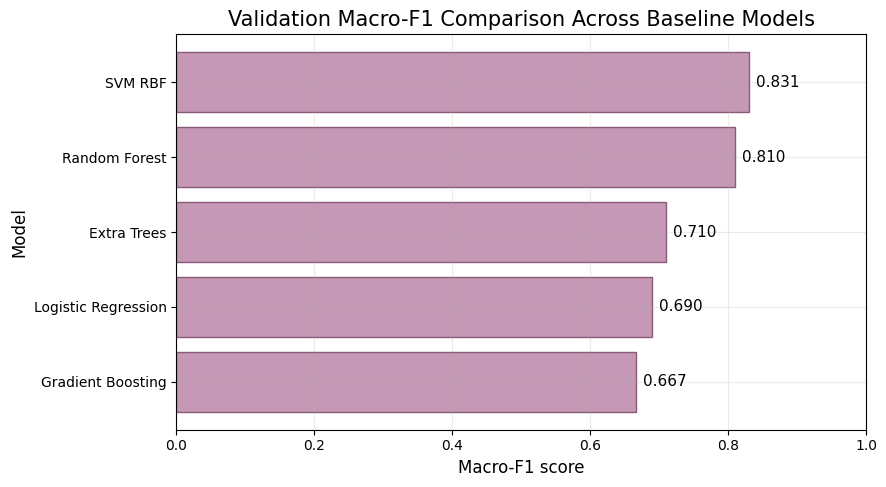

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6_validation_model_comparison.png


In [15]:
fig_path = FIGURE_DIR / "notebook6_validation_model_comparison.png"

plot_df = validation_results_df.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["model"],
    plot_df["macro_f1"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Validation Macro-F1 Comparison Across Baseline Models")
plt.xlabel("Macro-F1 score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_df["macro_f1"]):
    plt.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [16]:
best_row = validation_results_df.sort_values(
    ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
    ascending=False
).iloc[0]

best_model_name = best_row["model"]
best_model = trained_models[best_model_name]

print("Best model selected based on validation macro-F1:")
print(best_model_name)

display(best_row)

Best model selected based on validation macro-F1:
SVM RBF


dataset                  validation
model                       SVM RBF
accuracy                   0.902778
precision_mi               0.965517
recall_sensitivity_mi      0.918033
specificity_healthy        0.818182
f1_mi                      0.941176
macro_f1                   0.830588
balanced_accuracy          0.868107
tn                                9
fp                                2
fn                                5
tp                               56
roc_auc                    0.938897
Name: 1, dtype: object

# Evaluate best model on test set

Test results with default threshold:
dataset: test
model: SVM RBF
accuracy: 0.8529
precision_mi: 0.9792
recall_sensitivity_mi: 0.8393
specificity_healthy: 0.9167
f1_mi: 0.9038
macro_f1: 0.7957
balanced_accuracy: 0.8780
tn: 11
fp: 1
fn: 9
tp: 47
roc_auc: 0.9375

Classification report:
                 precision    recall  f1-score   support

Healthy Control       0.55      0.92      0.69        12
             MI       0.98      0.84      0.90        56

       accuracy                           0.85        68
      macro avg       0.76      0.88      0.80        68
   weighted avg       0.90      0.85      0.87        68



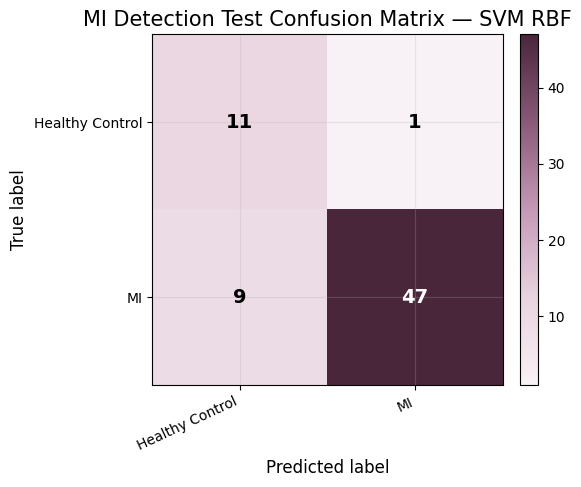

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6_test_confusion_matrix_default.png


In [17]:
y_test_pred_default = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_test_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_test_score = best_model.decision_function(X_test)

test_default_result = evaluate_binary_classifier(
    y_test,
    y_test_pred_default,
    y_score=y_test_score,
    model_name=best_model_name,
    dataset_name="test"
)

print("Test results with default threshold:")
for key, value in test_default_result.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred_default,
    target_names=["Healthy Control", "MI"],
    zero_division=0
))

cm_default = confusion_matrix(y_test, y_test_pred_default, labels=[0, 1])

fig_path = FIGURE_DIR / "notebook6_test_confusion_matrix_default.png"

plot_confusion_matrix_custom(
    cm_default,
    title=f"MI Detection Test Confusion Matrix — {best_model_name}",
    output_path=fig_path
)

print("Saved figure to:", fig_path)

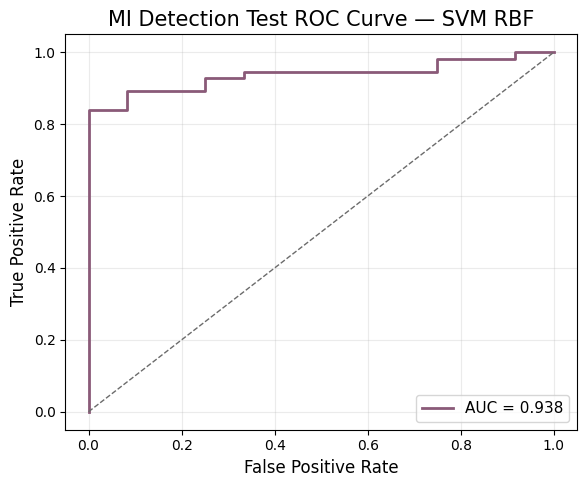

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6_test_roc_curve_default.png


In [18]:
fig_path = FIGURE_DIR / "notebook6_test_roc_curve_default.png"

plot_roc_curve_custom(
    y_test,
    y_test_score,
    title=f"MI Detection Test ROC Curve — {best_model_name}",
    output_path=fig_path
)

print("Saved figure to:", fig_path)

# Threshold tuning using validation set

In [19]:
if hasattr(best_model, "predict_proba"):
    y_val_score_best = best_model.predict_proba(X_val)[:, 1]
else:
    y_val_score_best = best_model.decision_function(X_val)

print("Validation score range:")
print("min:", np.min(y_val_score_best))
print("max:", np.max(y_val_score_best))
print("mean:", np.mean(y_val_score_best))

Validation score range:
min: 0.1328962905457788
max: 0.9916570754367
mean: 0.8443722439999208


In [20]:
thresholds = np.linspace(
    np.min(y_val_score_best),
    np.max(y_val_score_best),
    300
)

threshold_results = []

for threshold in thresholds:
    y_val_pred_thr = (y_val_score_best >= threshold).astype(int)

    result = evaluate_binary_classifier(
        y_val,
        y_val_pred_thr,
        y_score=y_val_score_best,
        model_name=best_model_name,
        dataset_name="validation"
    )

    result["threshold"] = threshold
    threshold_results.append(result)

threshold_results_df = pd.DataFrame(threshold_results)

# Strategy 1: best macro-F1
best_macro_f1_row = threshold_results_df.sort_values(
    ["macro_f1", "recall_sensitivity_mi", "specificity_healthy"],
    ascending=False
).iloc[0]

# Strategy 2: recall priority with specificity >= 0.70
candidate_df = threshold_results_df[
    threshold_results_df["specificity_healthy"] >= 0.70
].copy()

if len(candidate_df) > 0:
    recall_priority_row = candidate_df.sort_values(
        ["recall_sensitivity_mi", "macro_f1", "specificity_healthy"],
        ascending=False
    ).iloc[0]
else:
    recall_priority_row = best_macro_f1_row.copy()

threshold_summary_df = pd.DataFrame([
    {
        "strategy": "best_macro_f1",
        **best_macro_f1_row.to_dict()
    },
    {
        "strategy": "recall_priority_spec_ge_0.70",
        **recall_priority_row.to_dict()
    }
])

display(threshold_summary_df[
    [
        "strategy",
        "threshold",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp"
    ]
])

,strategy,threshold,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,best_macro_f1,0.764760,0.916667,0.982456,0.918033,0.909091,0.949153,0.859192,0.913562,0.938897,10,1,5,56
1,recall_priority_spec_ge_0.70,0.598178,0.916667,0.966102,0.934426,0.818182,0.950000,0.850000,0.876304,0.938897,9,2,4,57


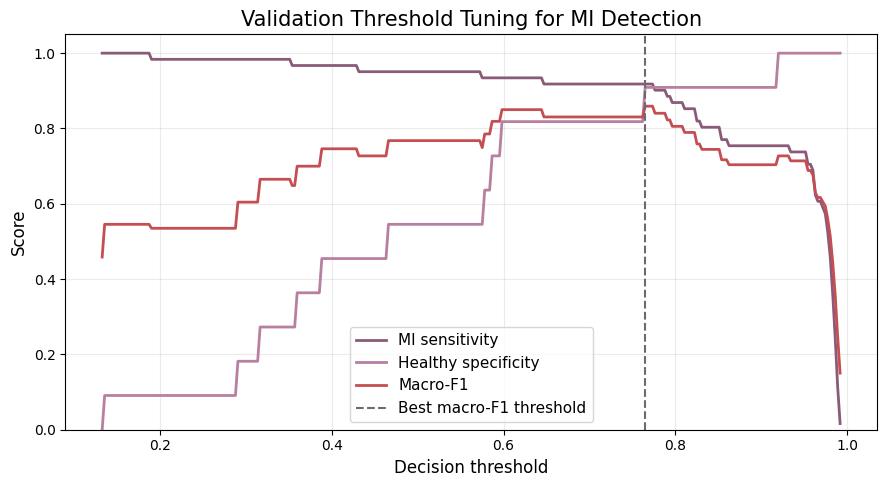

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6_threshold_tuning_validation.png


In [21]:
fig_path = FIGURE_DIR / "notebook6_threshold_tuning_validation.png"

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall_sensitivity_mi"],
    label="MI sensitivity",
    color=PURPLE_DARK,
    linewidth=2
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["specificity_healthy"],
    label="Healthy specificity",
    color=PURPLE_MID,
    linewidth=2
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["macro_f1"],
    label="Macro-F1",
    color=RED_SOFT,
    linewidth=2
)

plt.axvline(
    best_macro_f1_row["threshold"],
    color=GRAY,
    linestyle="--",
    label="Best macro-F1 threshold"
)

plt.title("Validation Threshold Tuning for MI Detection")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [22]:
# Choose final threshold
SELECTED_THRESHOLD_STRATEGY = "best_macro_f1"

if SELECTED_THRESHOLD_STRATEGY == "best_macro_f1":
    selected_threshold = best_macro_f1_row["threshold"]
    selected_threshold_row = best_macro_f1_row
else:
    selected_threshold = recall_priority_row["threshold"]
    selected_threshold_row = recall_priority_row

print("Selected threshold strategy:", SELECTED_THRESHOLD_STRATEGY)
print("Selected threshold:", selected_threshold)

display(selected_threshold_row)

Selected threshold strategy: best_macro_f1
Selected threshold: 0.764760413207995


dataset                  validation
model                       SVM RBF
accuracy                   0.916667
precision_mi               0.982456
recall_sensitivity_mi      0.918033
specificity_healthy        0.909091
f1_mi                      0.949153
macro_f1                   0.859192
balanced_accuracy          0.913562
tn                               10
fp                                1
fn                                5
tp                               56
roc_auc                    0.938897
threshold                   0.76476
Name: 220, dtype: object

Test results with tuned threshold:
dataset: test
model: SVM RBF
accuracy: 0.8529
precision_mi: 0.9792
recall_sensitivity_mi: 0.8393
specificity_healthy: 0.9167
f1_mi: 0.9038
macro_f1: 0.7957
balanced_accuracy: 0.8780
tn: 11
fp: 1
fn: 9
tp: 47
roc_auc: 0.9375
threshold: 0.7648
threshold_strategy: best_macro_f1

Classification report:
                 precision    recall  f1-score   support

Healthy Control       0.55      0.92      0.69        12
             MI       0.98      0.84      0.90        56

       accuracy                           0.85        68
      macro avg       0.76      0.88      0.80        68
   weighted avg       0.90      0.85      0.87        68



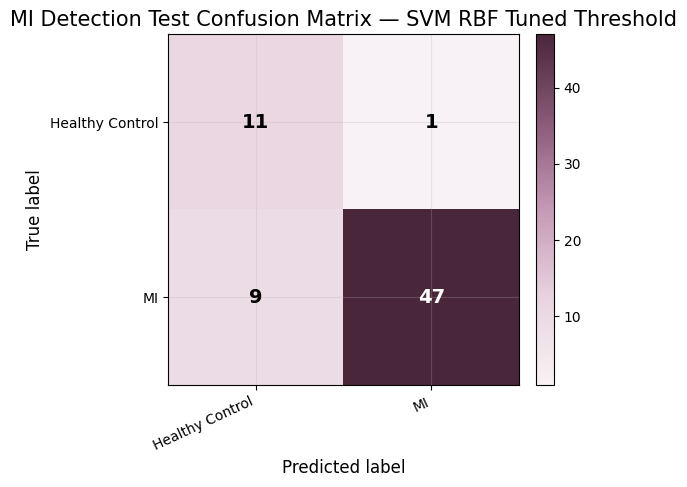

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6_test_confusion_matrix_tuned.png


In [23]:
# Cell 21
y_test_pred_tuned = (y_test_score >= selected_threshold).astype(int)

test_tuned_result = evaluate_binary_classifier(
    y_test,
    y_test_pred_tuned,
    y_score=y_test_score,
    model_name=best_model_name,
    dataset_name="test"
)

test_tuned_result["threshold"] = selected_threshold
test_tuned_result["threshold_strategy"] = SELECTED_THRESHOLD_STRATEGY

print("Test results with tuned threshold:")
for key, value in test_tuned_result.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred_tuned,
    target_names=["Healthy Control", "MI"],
    zero_division=0
))

cm_tuned = confusion_matrix(y_test, y_test_pred_tuned, labels=[0, 1])

fig_path = FIGURE_DIR / "notebook6_test_confusion_matrix_tuned.png"

plot_confusion_matrix_custom(
    cm_tuned,
    title=f"MI Detection Test Confusion Matrix — {best_model_name} Tuned Threshold",
    output_path=fig_path
)

print("Saved figure to:", fig_path)

Test results with recall-priority threshold:
dataset: test
model: SVM RBF
accuracy: 0.8676
precision_mi: 0.9434
recall_sensitivity_mi: 0.8929
specificity_healthy: 0.7500
f1_mi: 0.9174
macro_f1: 0.7920
balanced_accuracy: 0.8214
tn: 9
fp: 3
fn: 6
tp: 50
roc_auc: 0.9375
threshold: 0.5982
threshold_strategy: recall_priority_spec_ge_0.70


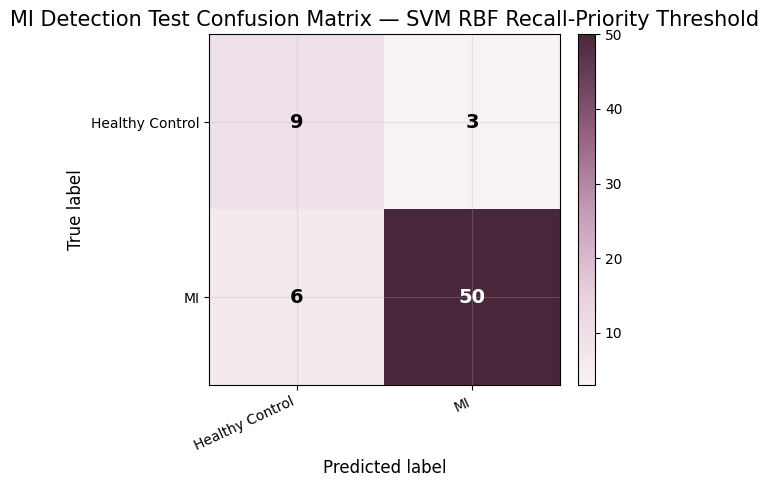

In [24]:
# =========================
# Evaluate recall-priority threshold on test set
# =========================

recall_priority_threshold = recall_priority_row["threshold"]

y_test_pred_recall_priority = (y_test_score >= recall_priority_threshold).astype(int)

test_recall_priority_result = evaluate_binary_classifier(
    y_test,
    y_test_pred_recall_priority,
    y_score=y_test_score,
    model_name=best_model_name,
    dataset_name="test"
)

test_recall_priority_result["threshold"] = recall_priority_threshold
test_recall_priority_result["threshold_strategy"] = "recall_priority_spec_ge_0.70"

print("Test results with recall-priority threshold:")
for key, value in test_recall_priority_result.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

cm_recall_priority = confusion_matrix(y_test, y_test_pred_recall_priority, labels=[0, 1])

plot_confusion_matrix_custom(
    cm_recall_priority,
    title=f"MI Detection Test Confusion Matrix — {best_model_name} Recall-Priority Threshold",
    output_path=FIGURE_DIR / "notebook6_test_confusion_matrix_recall_priority.png"
)

In [25]:
comparison_df = pd.DataFrame([
    {
        "setting": "default_threshold",
        **test_default_result
    },
    {
        "setting": "tuned_threshold",
        **test_tuned_result
    }
])

display(comparison_df[
    [
        "setting",
        "model",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp"
    ]
])

,setting,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,default_threshold,SVM RBF,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.9375,11,1,9,47
1,tuned_threshold,SVM RBF,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.9375,11,1,9,47


# Inspect selected features

In [26]:
def get_selected_features_from_pipeline(model, feature_cols):
    if "select" not in model.named_steps:
        return feature_cols

    selector = model.named_steps["select"]
    selected_mask = selector.get_support()

    selected_features = [
        feature for feature, selected in zip(feature_cols, selected_mask)
        if selected
    ]

    return selected_features


selected_features = get_selected_features_from_pipeline(best_model, clean_feature_cols)

print("Number of selected features:", len(selected_features))
print("First 50 selected features:")
print(selected_features[:50])

Number of selected features: 200
First 50 selected features:
['i_stat_median', 'i_stat_abs_mean', 'i_stat_kurtosis', 'ii_stat_median', 'ii_stat_min', 'ii_stat_skewness', 'ii_stat_zcr', 'iii_stat_median', 'iii_stat_skewness', 'avr_stat_median', 'avr_stat_abs_mean', 'avr_stat_zcr', 'avl_stat_skewness', 'avf_stat_median', 'avf_stat_min', 'avf_stat_skewness', 'avf_stat_zcr', 'v1_stat_kurtosis', 'v1_stat_entropy', 'v3_stat_median', 'v4_stat_median', 'v5_stat_median', 'v5_stat_abs_mean', 'v5_stat_zcr', 'v6_stat_median', 'v6_stat_zcr', 'i_morph_baseline_mean', 'i_morph_baseline_median', 'i_morph_st_level_mean', 'i_morph_st_level_median', 'i_morph_t_amp_mean', 'i_morph_t_amp_median', 'i_morph_t_amp_min', 'i_morph_t_max_amp_mean', 'i_morph_t_max_amp_median', 'i_morph_t_max_amp_min', 'i_morph_t_min_amp_mean', 'i_morph_t_min_amp_median', 'i_morph_t_area_mean', 'i_morph_t_area_median', 'i_morph_t_area_min', 'ii_morph_q_amp_min', 'ii_morph_qrs_anchor_amp_mean', 'ii_morph_qrs_anchor_amp_median', 'ii

In [27]:
def assign_feature_group(col):
    if col.startswith("rhythm_"):
        return "rhythm"
    elif col.startswith("contrast_"):
        return "lead_contrast"
    elif "_group_" in col:
        return "lead_group"
    elif "_morph_" in col:
        return "lead_specific_morphology"
    elif "_ratio_" in col:
        return "lead_specific_ratio"
    elif "_stat_" in col:
        return "lead_specific_statistical"
    else:
        return "other"


selected_feature_group_df = pd.DataFrame({
    "feature": selected_features
})

selected_feature_group_df["feature_group"] = selected_feature_group_df["feature"].apply(assign_feature_group)

selected_group_counts = (
    selected_feature_group_df["feature_group"]
    .value_counts()
    .reset_index()
)

selected_group_counts.columns = ["feature_group", "n_selected_features"]

display(selected_group_counts)

,feature_group,n_selected_features
0,lead_specific_morphology,146
1,lead_specific_statistical,26
2,lead_group,19
3,lead_contrast,8
4,lead_specific_ratio,1


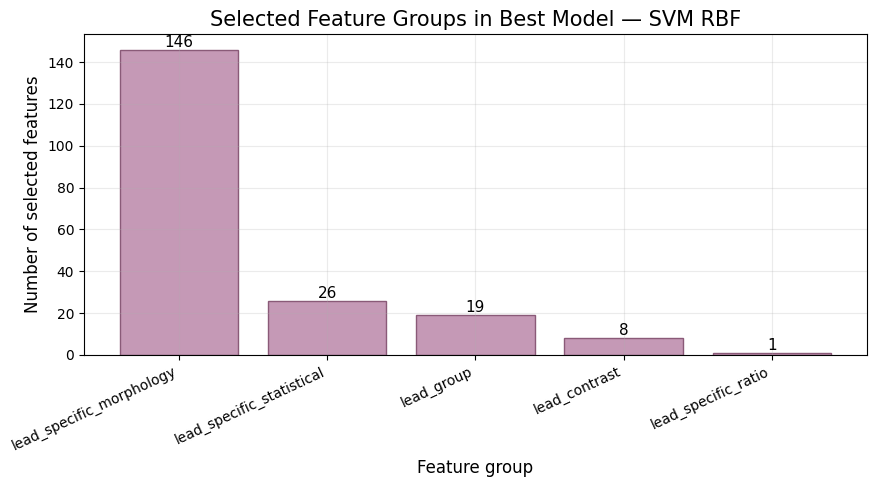

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6_selected_feature_group_counts.png


In [28]:
fig_path = FIGURE_DIR / "notebook6_selected_feature_group_counts.png"

plt.figure(figsize=(9, 5))

bars = plt.bar(
    selected_group_counts["feature_group"],
    selected_group_counts["n_selected_features"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title(f"Selected Feature Groups in Best Model — {best_model_name}")
plt.xlabel("Feature group")
plt.ylabel("Number of selected features")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [29]:
validation_results_path = TABLE_DIR / "notebook6_validation_model_comparison.csv"
test_comparison_path = TABLE_DIR / "notebook6_test_threshold_comparison.csv"
threshold_results_path = TABLE_DIR / "notebook6_validation_threshold_search.csv"
selected_features_path = TABLE_DIR / "notebook6_selected_features.csv"

validation_results_df.to_csv(validation_results_path, index=False, encoding="utf-8-sig")
comparison_df.to_csv(test_comparison_path, index=False, encoding="utf-8-sig")
threshold_results_df.to_csv(threshold_results_path, index=False, encoding="utf-8-sig")
selected_feature_group_df.to_csv(selected_features_path, index=False, encoding="utf-8-sig")

print("Saved:")
print(validation_results_path)
print(test_comparison_path)
print(threshold_results_path)
print(selected_features_path)

Saved:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6_validation_model_comparison.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6_test_threshold_comparison.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6_validation_threshold_search.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6_selected_features.csv


In [30]:
test_predictions_df = test_df[
    [
        "patient_id",
        "record_id",
        "reason_for_admission",
        "mi_detected",
        "split"
    ]
].copy()

test_predictions_df["y_true"] = y_test.values
test_predictions_df["score_mi"] = y_test_score
test_predictions_df["pred_default"] = y_test_pred_default
test_predictions_df["pred_tuned"] = y_test_pred_tuned

test_predictions_path = TABLE_DIR / "notebook6_test_predictions.csv"

test_predictions_df.to_csv(test_predictions_path, index=False, encoding="utf-8-sig")

print("Saved test predictions to:")
print(test_predictions_path)

display(test_predictions_df.head())

Saved test predictions to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6_test_predictions.csv


,patient_id,record_id,reason_for_admission,mi_detected,split,y_true,score_mi,pred_default,pred_tuned
3,patient002,s0015lre,Myocardial infarction,1,test,1,0.986803,1,1
5,patient004,s0020are,Myocardial infarction,1,test,1,0.987184,1,1
6,patient004,s0020bre,Myocardial infarction,1,test,1,0.988105,1,1
19,patient008,s0028lre,Myocardial infarction,1,test,1,0.933514,1,1
20,patient008,s0037lre,Myocardial infarction,1,test,1,0.979391,1,1


In [31]:
print("Notebook 6 completed.")

print("\nBest model:", best_model_name)
print("Selected threshold:", selected_threshold)

print("\nValidation model comparison:")
display(validation_results_df.sort_values("macro_f1", ascending=False))

print("\nTest comparison:")
display(comparison_df[
    [
        "setting",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp"
    ]
])

Notebook 6 completed.

Best model: SVM RBF
Selected threshold: 0.764760413207995

Validation model comparison:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc
1,validation,SVM RBF,0.902778,0.965517,0.918033,0.818182,0.941176,0.830588,0.868107,9,2,5,56,0.938897
2,validation,Random Forest,0.916667,0.923077,0.983607,0.545455,0.952381,0.809524,0.764531,6,5,1,60,0.956781
3,validation,Extra Trees,0.861111,0.904762,0.934426,0.454545,0.919355,0.709677,0.694486,5,6,4,57,0.946349
0,validation,Logistic Regression,0.805556,0.927273,0.836066,0.636364,0.879310,0.689655,0.736215,7,4,10,51,0.836066
4,validation,Gradient Boosting,0.847222,0.890625,0.934426,0.363636,0.912000,0.666526,0.649031,4,7,4,57,0.934426



Test comparison:


,setting,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,default_threshold,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.9375,11,1,9,47
1,tuned_threshold,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.9375,11,1,9,47


Patient-level test results:
dataset: patient_level_test
model: SVM RBF
accuracy: 0.8667
precision_mi: 0.9500
recall_sensitivity_mi: 0.8636
specificity_healthy: 0.8750
f1_mi: 0.9048
macro_f1: 0.8413
balanced_accuracy: 0.8693
tn: 7
fp: 1
fn: 3
tp: 19
roc_auc: 0.9545


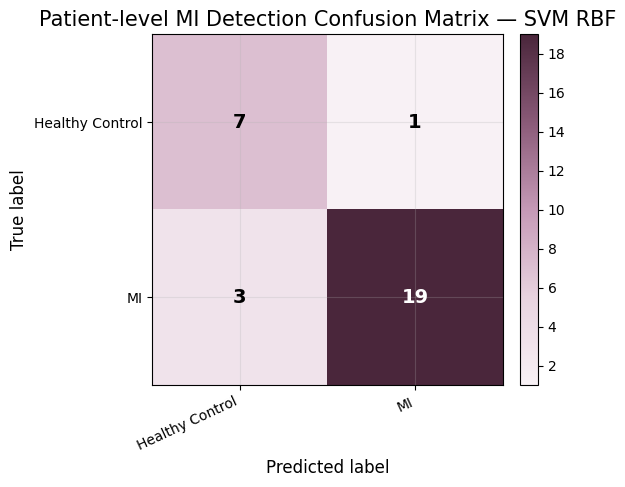

,patient_id,y_true,mean_score_mi,n_records,pred_default
0,patient002,1,0.986803,1,1
1,patient004,1,0.987644,2,1
2,patient008,1,0.960120,3,1
3,patient026,1,0.982229,2,1
4,patient035,1,0.973275,4,1


In [32]:
# =========================
# Patient-level test evaluation
# =========================

patient_test_eval_df = test_predictions_df.copy()

patient_score_df = (
    patient_test_eval_df
    .groupby("patient_id")
    .agg(
        y_true=("y_true", lambda x: x.mode().iloc[0]),
        mean_score_mi=("score_mi", "mean"),
        n_records=("record_id", "count")
    )
    .reset_index()
)

patient_score_df["pred_default"] = (
    patient_score_df["mean_score_mi"] >= selected_threshold
).astype(int)

patient_level_result = evaluate_binary_classifier(
    patient_score_df["y_true"],
    patient_score_df["pred_default"],
    y_score=patient_score_df["mean_score_mi"],
    model_name=best_model_name,
    dataset_name="patient_level_test"
)

print("Patient-level test results:")
for key, value in patient_level_result.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

cm_patient = confusion_matrix(
    patient_score_df["y_true"],
    patient_score_df["pred_default"],
    labels=[0, 1]
)

plot_confusion_matrix_custom(
    cm_patient,
    title=f"Patient-level MI Detection Confusion Matrix — {best_model_name}",
    output_path=FIGURE_DIR / "notebook6_patient_level_confusion_matrix.png"
)

display(patient_score_df.head())

In [33]:
comparison_df = pd.DataFrame([
    {
        "setting": "default_model_decision",
        **test_default_result
    },
    {
        "setting": "best_macro_f1_threshold",
        **test_tuned_result
    },
    {
        "setting": "recall_priority_threshold",
        **test_recall_priority_result
    }
])

display(comparison_df[
    [
        "setting",
        "model",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp"
    ]
])

,setting,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,default_model_decision,SVM RBF,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.9375,11,1,9,47
1,best_macro_f1_threshold,SVM RBF,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.9375,11,1,9,47
2,recall_priority_threshold,SVM RBF,0.867647,0.943396,0.892857,0.750000,0.917431,0.792049,0.821429,0.9375,9,3,6,50


In [35]:
patient_level_summary_df = pd.DataFrame([patient_level_result])

display(patient_level_summary_df[
    [
        "dataset",
        "model",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp"
    ]
])

,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
0,patient_level_test,SVM RBF,0.866667,0.95,0.863636,0.875,0.904762,0.84127,0.869318,0.954545,7,1,3,19


# Cross Validation

In [36]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X_all_trainval = pd.concat([X_train, X_val], axis=0)
y_all_trainval = pd.concat([y_train, y_val], axis=0)

groups_all_trainval = pd.concat([
    train_df["patient_id"],
    val_df["patient_id"]
], axis=0)

print("Train + validation shape:", X_all_trainval.shape)
print("Number of patients:", groups_all_trainval.nunique())
print("Class distribution:")
print(y_all_trainval.value_counts())

Train + validation shape: (380, 1304)
Number of patients: 170
Class distribution:
mi_detected
1    312
0     68
Name: count, dtype: int64


In [37]:
cv_results = []

for fold_idx, (train_idx, val_idx) in enumerate(
    cv.split(X_all_trainval, y_all_trainval, groups_all_trainval),
    start=1
):
    X_cv_train = X_all_trainval.iloc[train_idx]
    X_cv_val = X_all_trainval.iloc[val_idx]

    y_cv_train = y_all_trainval.iloc[train_idx]
    y_cv_val = y_all_trainval.iloc[val_idx]

    model_cv = clone(best_model)
    model_cv.fit(X_cv_train, y_cv_train)

    y_cv_pred = model_cv.predict(X_cv_val)

    if hasattr(model_cv, "decision_function"):
        y_cv_score = model_cv.decision_function(X_cv_val)
    else:
        y_cv_score = model_cv.predict_proba(X_cv_val)[:, 1]

    result = evaluate_binary_classifier(
        y_cv_val,
        y_cv_pred,
        y_score=y_cv_score,
        model_name="SVM RBF",
        dataset_name=f"cv_fold_{fold_idx}"
    )

    result["fold"] = fold_idx
    result["n_train_records"] = len(train_idx)
    result["n_val_records"] = len(val_idx)
    result["n_train_patients"] = groups_all_trainval.iloc[train_idx].nunique()
    result["n_val_patients"] = groups_all_trainval.iloc[val_idx].nunique()

    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,fold,n_train_records,n_val_records,n_train_patients,n_val_patients
0,cv_fold_1,SVM RBF,0.907895,0.951613,0.936508,0.769231,0.944000,0.842370,0.852869,10,3,4,59,0.899878,1,304,76,137,33
1,cv_fold_2,SVM RBF,0.842105,0.916667,0.887097,0.642857,0.901639,0.750820,0.764977,9,5,7,55,0.934332,2,304,76,136,34
2,cv_fold_3,SVM RBF,0.868421,0.964286,0.870968,0.857143,0.915254,0.810568,0.864055,12,2,8,54,0.922811,3,304,76,136,34
3,cv_fold_4,SVM RBF,0.907895,0.982759,0.904762,0.923077,0.942149,0.858171,0.913919,12,1,6,57,0.959707,4,304,76,135,35
4,cv_fold_5,SVM RBF,0.881579,0.981818,0.870968,0.928571,0.923077,0.832967,0.899770,13,1,8,54,0.948157,5,304,76,136,34


In [38]:
cv_summary_df = cv_results_df[
    [
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc"
    ]
].agg(["mean", "std"]).T.reset_index()

cv_summary_df.columns = ["metric", "mean", "std"]

display(cv_summary_df)

,metric,mean,std
0,accuracy,0.881579,0.027912
1,precision_mi,0.959428,0.027198
2,recall_sensitivity_mi,0.894060,0.027529
3,specificity_healthy,0.824176,0.120065
4,f1_mi,0.925224,0.018022
5,macro_f1,0.818979,0.041819
6,balanced_accuracy,0.859118,0.058270
7,roc_auc,0.932977,0.023161


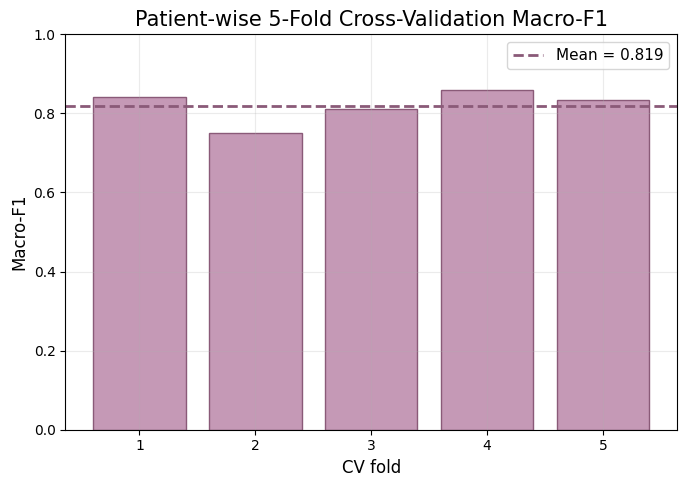

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6_patient_wise_cv_macro_f1.png


In [39]:
fig_path = FIGURE_DIR / "notebook6_patient_wise_cv_macro_f1.png"

plt.figure(figsize=(7, 5))

plt.bar(
    cv_results_df["fold"].astype(str),
    cv_results_df["macro_f1"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.axhline(
    cv_results_df["macro_f1"].mean(),
    color=PURPLE_DARK,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {cv_results_df['macro_f1'].mean():.3f}"
)

plt.title("Patient-wise 5-Fold Cross-Validation Macro-F1")
plt.xlabel("CV fold")
plt.ylabel("Macro-F1")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)